# Refine CD4 Naive cluster of reference dataset

In [1]:
%load_ext autoreload

In [2]:
import numpy as np
import scanpy as sc

In [3]:
adata = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/raw/"
    "public-anndata_project-232_1___published__87833b35-f160-46eb-a827-b7593c473084.AIDAv2DataFreezeCT.h5ad",
)

In [4]:
adata_raw = adata.raw.to_adata()
del adata.raw

In [5]:
adata

AnnData object with n_obs × n_vars = 1265624 × 36503
    obs: 'mapped_reference_assembly', 'mapped_reference_annotation', 'alignment_software', 'library_uuid', 'assay_ontology_term_id', 'library_starting_quantity', 'is_primary_data', 'cell_type--cell_ontology_term_id', 'author_cell_type', 'sample_uuid', 'tissue_ontology_term_id', 'development_stage--cell_ontology_term_id', 'sample_derivation_process', 'donor_BMI_at_collection', 'tissue_type', 'suspension_derivation_process', 'suspension_enriched_cell_types', 'suspension_percent_cell_viability', 'suspension_uuid', 'suspension_type', 'donor_id', 'self_reported_ethnicity--cell_ontology_term_id', 'donor_living_at_sample_collection', 'organism_ontology_term_id', 'disease_ontology_term_id', 'sex--cell_ontology_term_id', 'nCount_RNA', 'nFeature_RNA', 'pMito', 'NODG', 'nUMI', 'Country', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'author_cell_type--cell_ful

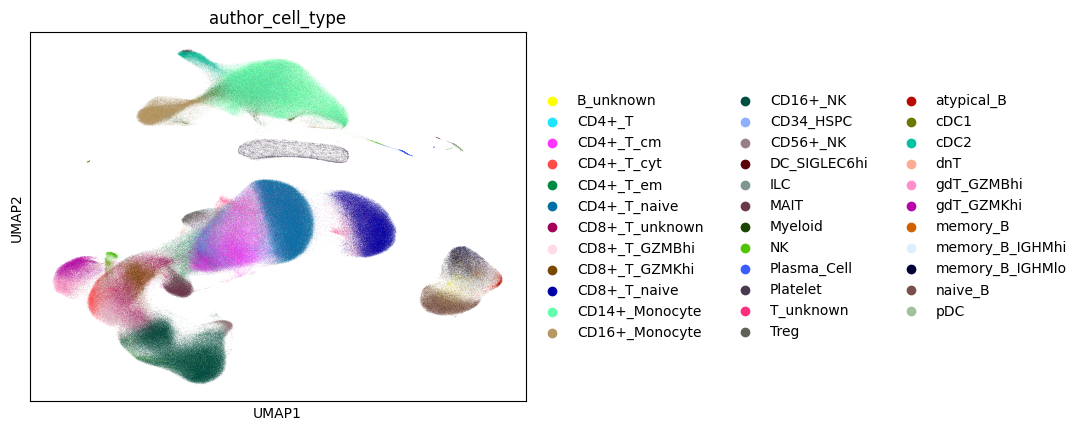

In [6]:
sc.pl.umap(adata, color=["author_cell_type"])

## Refine CD4 Naive cluster

In [7]:
CD4_Naive_clusters = ["CD4+_T", "CD4+_T_naive"]

In [8]:
adata_CD4_Naive = adata[
    adata.obs["author_cell_type"].isin(CD4_Naive_clusters)
]
adata_CD4_Naive_raw = adata_raw[
    adata.obs["author_cell_type"].isin(CD4_Naive_clusters)
]

In [9]:
adata_CD4_Naive

View of AnnData object with n_obs × n_vars = 197716 × 36503
    obs: 'mapped_reference_assembly', 'mapped_reference_annotation', 'alignment_software', 'library_uuid', 'assay_ontology_term_id', 'library_starting_quantity', 'is_primary_data', 'cell_type--cell_ontology_term_id', 'author_cell_type', 'sample_uuid', 'tissue_ontology_term_id', 'development_stage--cell_ontology_term_id', 'sample_derivation_process', 'donor_BMI_at_collection', 'tissue_type', 'suspension_derivation_process', 'suspension_enriched_cell_types', 'suspension_percent_cell_viability', 'suspension_uuid', 'suspension_type', 'donor_id', 'self_reported_ethnicity--cell_ontology_term_id', 'donor_living_at_sample_collection', 'organism_ontology_term_id', 'disease_ontology_term_id', 'sex--cell_ontology_term_id', 'nCount_RNA', 'nFeature_RNA', 'pMito', 'NODG', 'nUMI', 'Country', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'author_cell_type--c

In [10]:
adata_CD4_Naive.var.index = adata_CD4_Naive.var["feature_name"].astype(str)
adata_CD4_Naive_raw.var.index = adata_CD4_Naive_raw.var["feature_name"].astype(str)

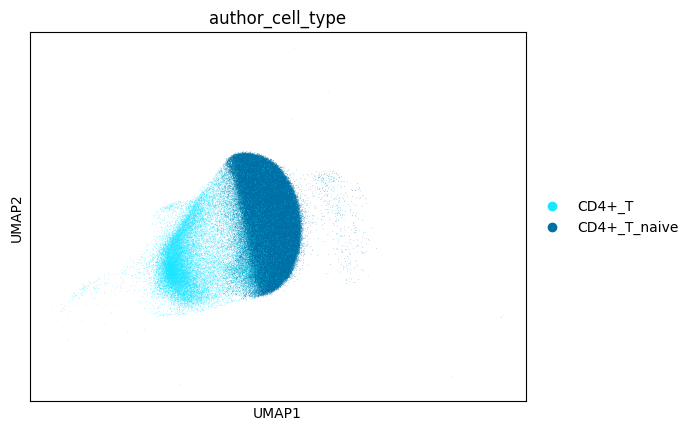

In [11]:
sc.pl.umap(adata_CD4_Naive, color=["author_cell_type"])

In [12]:
sc.pp.pca(adata_CD4_Naive)

In [13]:
sc.pp.neighbors(adata_CD4_Naive)

In [14]:
sc.tl.leiden(adata_CD4_Naive, resolution=0.025)

/tmp/ipykernel_462585/1053133345.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_CD4_Naive, resolution=0.025)


In [15]:
adata_CD4_Naive.obs.leiden.value_counts()

leiden
0    174740
1     22976
Name: count, dtype: int64

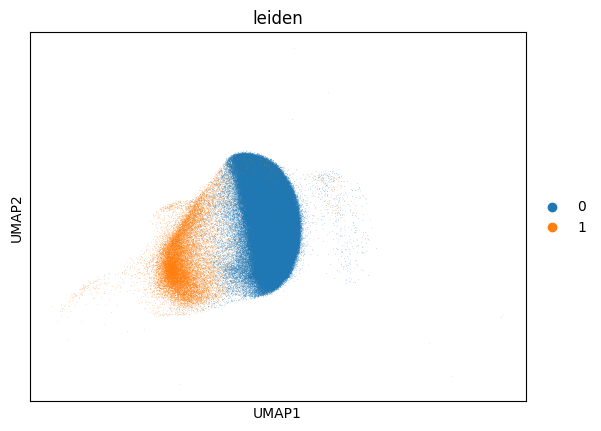

In [16]:
sc.pl.umap(adata_CD4_Naive, color="leiden")

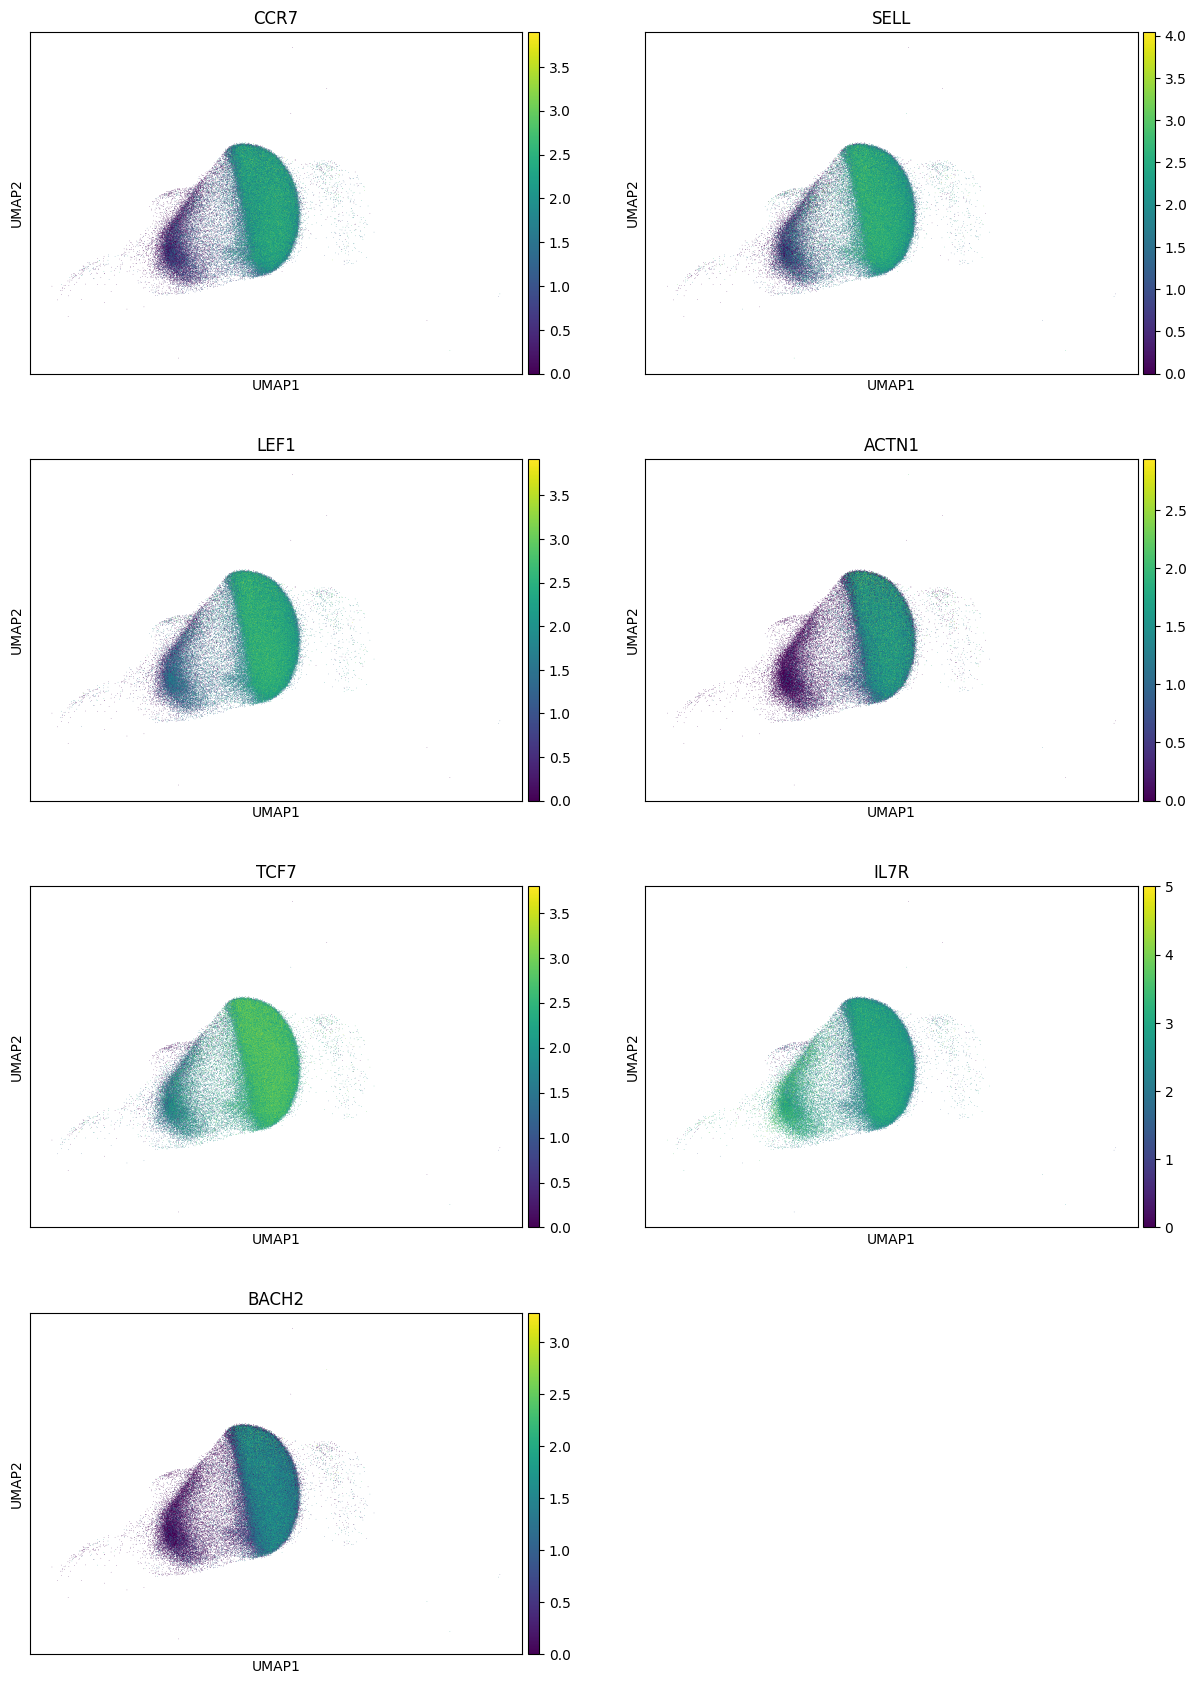

In [17]:
CD4_Naive_markers = ["CCR7", "SELL", "LEF1", "ACTN1", "TCF7", "IL7R", "BACH2"]

sc.pl.umap(
    adata_CD4_Naive, 
    color=CD4_Naive_markers,
    ncols=2
)

In [18]:
assert adata_CD4_Naive.var.index.equals(adata_CD4_Naive_raw.var.index)
adata_CD4_Naive_raw.obs["leiden"] = adata_CD4_Naive.obs["leiden"]

/tmp/ipykernel_462585/758376219.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_CD4_Naive_raw.obs["leiden"] = adata_CD4_Naive.obs["leiden"]


In [19]:
%autoreload
from sconnect.de_testing.testing import calc_pseudobulk_stats
from sconnect.de_testing.selection import (
    select_and_combine_de_results,
    sort_and_filter_de_genes_ova,
    sort_and_filter_de_genes_ava,
)

In [20]:
de_res_ova, de_res_ava = calc_pseudobulk_stats(
    adata_CD4_Naive_raw,
    cluster_label="leiden",
    sample_label="sample_uuid"
)

R[write to console]: data.table 1.15.4 using 8 threads (see ?getDTthreads).  
R[write to console]: Latest news: r-datatable.com

Calculating AVA AUROC scores: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:29<00:00, 29.52s/it]


In [21]:
res = select_and_combine_de_results(
    sort_and_filter_de_genes_ova(
        de_res_ova,
        logfc_threshold=0.,
        aucroc_threshold=0.0
    ),
    sort_and_filter_de_genes_ava(
        de_res_ava,
        logfc_threshold=0.,
        aucroc_threshold=0.0
    ),
    overlap_threshold=0.3,
    n_genes_ova=None,
    n_genes_ava=None
)

In [22]:
from IPython.display import display

In [23]:
for cluster in np.unique(adata_CD4_Naive_raw.obs.leiden):
    df = res[cluster]
    df = df.head(15)
    print(cluster)
    display(
        df.style
        .format("{:.2f}", subset=["logFC", "auroc"])
        .format("{:.3f}", subset=["adj.P.Val"])
    )
    print()

0


,logFC,adj.P.Val,auroc,reference
ID,,,,
AIF1,1.80,0.000,0.67,['all']
NOG,1.68,0.000,0.61,['all']
LRRN3,1.60,0.000,0.60,['all']
TMIGD2,1.56,0.000,0.64,['all']
ACTN1,1.55,0.000,0.71,['all']
CCR7,1.47,0.000,0.81,['all']
ADTRP,1.28,0.000,0.59,['all']
AK5,1.28,0.000,0.60,['all']
PECAM1,1.27,0.000,0.58,['all']



1


,logFC,adj.P.Val,auroc,reference
ID,,,,
LMNA,2.96,0.000,0.74,['all']
LGALS1,2.90,0.000,0.78,['all']
ANXA2,2.64,0.000,0.80,['all']
ITGB1,2.54,0.000,0.87,['all']
AHNAK,2.21,0.000,0.90,['all']
S100A4,2.21,0.000,0.92,['all']
CXCR3,2.21,0.000,0.68,['all']
GZMA,2.07,0.000,0.63,['all']
NIBAN1,2.05,0.000,0.65,['all']


In [24]:
for cluster in np.unique(adata_CD4_Naive_raw.obs.leiden):
    df = res[cluster]
    df.index.name = "ID"
    print(cluster)
    display(
        df
        .reset_index()
        .query(f'`ID` in {CD4_Naive_markers}')
        .style
        .format("{:.2f}", subset=["logFC", "auroc"])
        .format("{:.3f}", subset=["adj.P.Val"])
    )
    print()


0


,ID,logFC,adj.P.Val,auroc,reference
4,ACTN1,1.55,0.000,0.71,['all']
5,CCR7,1.47,0.000,0.81,['all']
10,BACH2,1.27,0.000,0.67,['all']
13,SELL,1.06,0.000,0.79,['all']
31,LEF1,0.91,0.000,0.78,['all']
77,TCF7,0.65,0.000,0.75,['all']



1


,ID,logFC,adj.P.Val,auroc,reference
605,IL7R,0.40,0.000,0.66,['all']


In [25]:
adata_CD4_Naive.obs["author_cell_type_fine"] = adata_CD4_Naive.obs["author_cell_type"].astype(str).copy()

adata_CD4_Naive.obs.loc[
    adata_CD4_Naive.obs.leiden.isin(["0"]), 
    "author_cell_type_fine"
] = "CD4+_T_naive"

In [26]:
adata_CD4_Naive.obs["author_cell_type_fine"] = adata_CD4_Naive.obs["author_cell_type_fine"].astype("category")
adata_CD4_Naive_raw.obs["author_cell_type_fine"] = adata_CD4_Naive.obs["author_cell_type_fine"].astype("category")

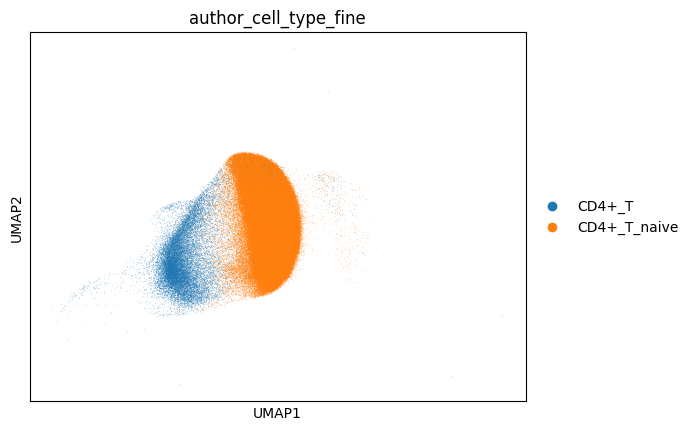

In [27]:
sc.pl.umap(adata_CD4_Naive, color=["author_cell_type_fine"])

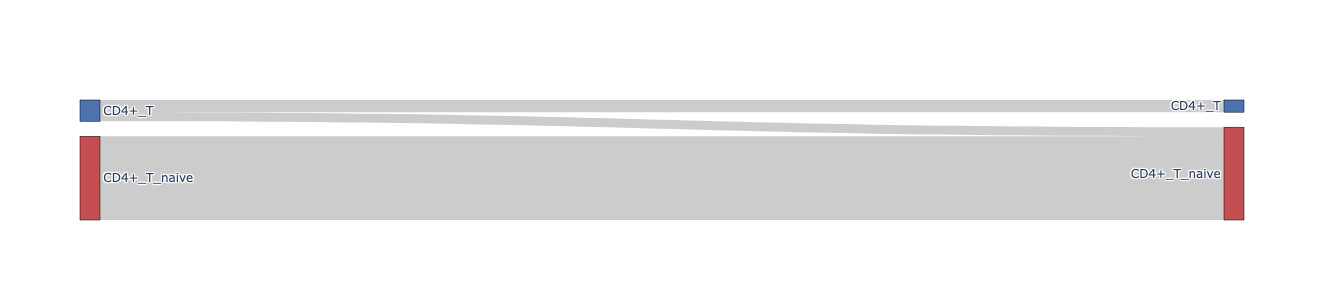

In [28]:
import plotly.graph_objects as go

from itertools import product


clusters_before = adata_CD4_Naive.obs.author_cell_type.unique().tolist()
clusters_after = adata_CD4_Naive.obs.author_cell_type_fine.unique().tolist()
change = {}

for ct in adata_CD4_Naive.obs["author_cell_type"].unique():
    change[ct] = adata_CD4_Naive[adata_CD4_Naive.obs["author_cell_type"] == ct].obs["author_cell_type_fine"].value_counts().to_dict()

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = clusters_before + clusters_after,
      color = ["#4C72B0", "#C44E52", "#4C72B0", "#C44E52"]
    ),
    link = dict(
      source = np.repeat(np.arange(len(clusters_before)), len(clusters_after)),
      target = np.tile(np.arange(len(clusters_before), len(clusters_after) + len(clusters_before)), len(clusters_before)),
      value = [change[ct1].get(ct2, 0) for ct1, ct2 in product(clusters_before, clusters_after)]
  ))])

fig.update_layout(
    width=500, height=300
)
fig.write_image("cluster_change_REF_CD4_Naive.svg")

fig.show()

In [29]:
# percentage of cells from the CD4+_T cluster which got reassigned to the new CD4+_T_naive cluster
change["CD4+_T"]["CD4+_T_naive"] / sum(change["CD4+_T"].values())

0.4280299251870324

In [30]:
adata_CD4_Naive.obs["author_cell_type_fine"].value_counts(normalize=True)

author_cell_type_fine
CD4+_T_naive    0.883995
CD4+_T          0.116005
Name: proportion, dtype: float64

In [31]:
adata_CD4_Naive.obs["author_cell_type"].value_counts(normalize=True)

author_cell_type
CD4+_T_naive    0.797184
CD4+_T          0.202816
Name: proportion, dtype: float64

In [32]:
de_res_ova, de_res_ava = calc_pseudobulk_stats(
    adata_CD4_Naive_raw,
    cluster_label="author_cell_type_fine",
    sample_label="sample_uuid"
)

Calculating AVA AUROC scores: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:29<00:00, 29.58s/it]


In [33]:
res_combined = select_and_combine_de_results(
    sort_and_filter_de_genes_ova(
        de_res_ova,
        logfc_threshold=0.
    ),
    sort_and_filter_de_genes_ava(
        de_res_ava,
        logfc_threshold=0.
    ),
    overlap_threshold=0.3
)

In [34]:
res_combined["CD4+_T_naive"]

,logFC,adj.P.Val,auroc,reference
ID,,,,
AIF1,1.800901,0.000000e+00,0.675004,[all]
NOG,1.682589,0.000000e+00,0.611401,[all]
LRRN3,1.599080,0.000000e+00,0.604318,[all]
TMIGD2,1.566877,0.000000e+00,0.636300,[all]
ACTN1,1.546752,0.000000e+00,0.712774,[all]
CCR7,1.476706,0.000000e+00,0.812275,[all]
AK5,1.278519,0.000000e+00,0.604529,[all]
SATB1,1.269733,0.000000e+00,0.738392,[all]
BACH2,1.265068,1.814611e-272,0.667605,[all]


In [35]:
res_combined["CD4+_T"]

,logFC,adj.P.Val,auroc,reference
ID,,,,
LMNA,2.958373,0.0,0.745110,[all]
LGALS1,2.900545,0.0,0.779766,[all]
ANXA2,2.641738,0.0,0.796411,[all]
ITGB1,2.535920,0.0,0.873809,[all]
AHNAK,2.209877,0.0,0.903802,[all]
S100A4,2.209396,0.0,0.916461,[all]
CXCR3,2.207158,0.0,0.679755,[all]
GZMA,2.074207,0.0,0.627548,[all]
NIBAN1,2.049887,0.0,0.655101,[all]


In [36]:
adata_CD4_Naive.write_h5ad("CD4_naive_subset.h5ad")

In [37]:
umap_x = adata_CD4_Naive.obsm["X_umap"][:, 0]
umap_y = adata_CD4_Naive.obsm["X_umap"][:, 1]


# remove outliers from UMAP plots
filtered_cells = (
    (umap_x < np.quantile(umap_x, 0.999)) &
    (umap_x > np.quantile(umap_x, 0.001)) &
    (umap_y < np.quantile(umap_y, 0.999)) &
    (umap_y > np.quantile(umap_y, 0.001))
)

adata_CD4_Naive_plot = adata_CD4_Naive[filtered_cells, :].copy()

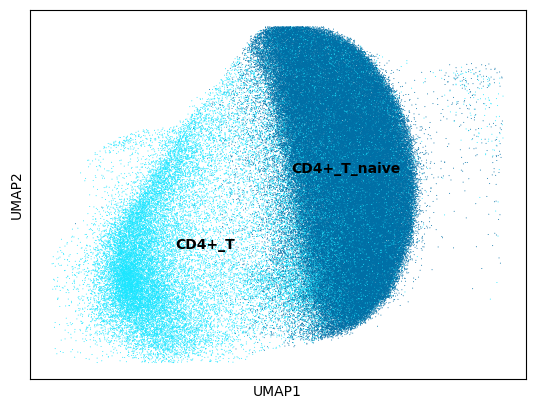

In [38]:
sc.pl.umap(
    adata_CD4_Naive_plot, 
    color=["author_cell_type"], 
    legend_loc="on data",
    title="",
    size=2,
    save="_original_clustering.png"
)

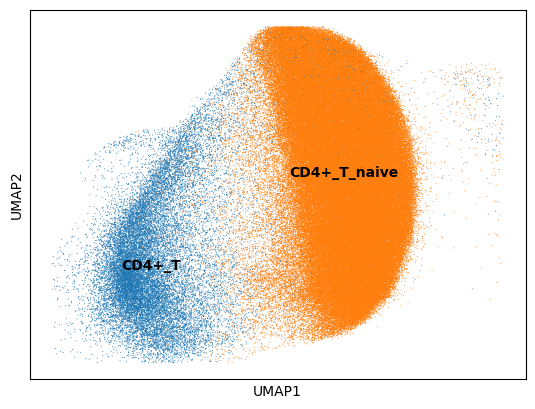

In [39]:
sc.pl.umap(
    adata_CD4_Naive_plot, 
    color=["author_cell_type_fine"], 
    legend_loc="on data",
    title="",
    size=2,
    save="_updated_clustering.png"
)

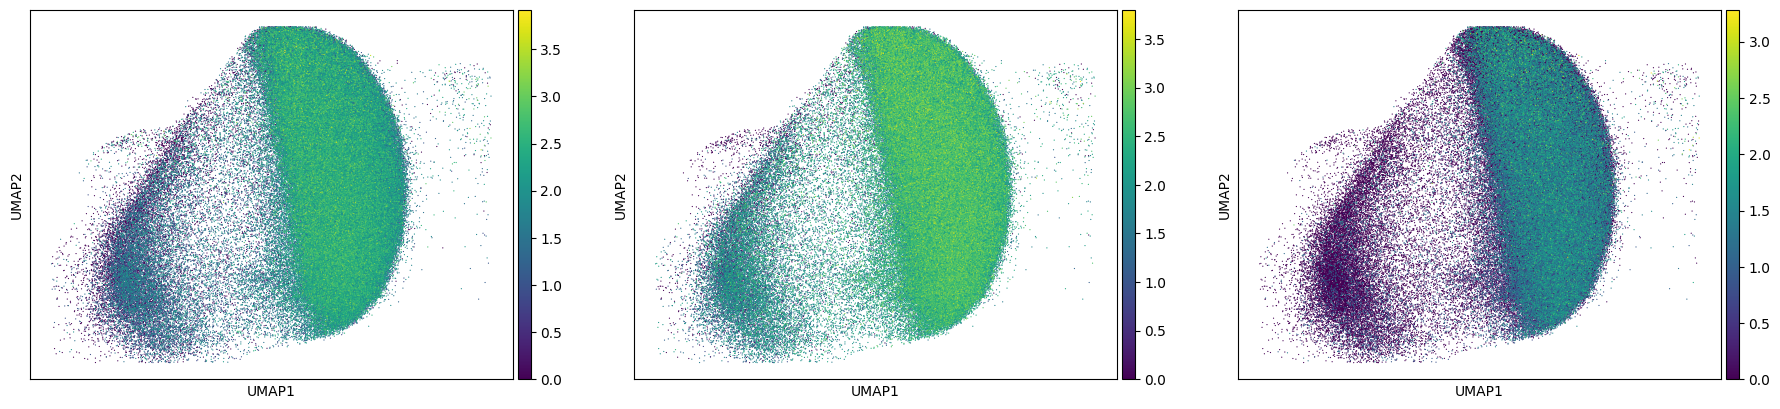

In [42]:
sc.pl.umap(
    adata_CD4_Naive_plot, 
    color=["LEF1", "TCF7", "BACH2"], 
    legend_loc="on data",
    title=["", "", ""],
    size=3,
    save="_BACH2.png"
)

## Update cell type annotations

In [37]:
import scanpy as sc

In [2]:
adata_CD4_Naive = sc.read_h5ad("CD4_naive_subset.h5ad")

In [3]:
adata_preprocessed = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/preprocessed/"
    "ced320a1-29f3-47c1-a735-513c7084d508_CAP.h5ad",
)

In [4]:
CD4_naive_cells = adata_CD4_Naive.obs[adata_CD4_Naive.obs.author_cell_type_fine == "CD4+_T_naive"].index.to_numpy()

In [5]:
adata_preprocessed.obs.cell_type_author.value_counts()

cell_type_author
CD14+_Monocyte     202124
CD4+_T_naive       157616
CD16+_NK           151655
CD4+_T_cm          110004
CD8+_T_naive        89029
T_unknown           54800
CD8+_T_unknown      53658
CD16+_Monocyte      46628
CD8+_T_GZMBhi       46528
CD4+_T              40100
naive_B             36778
CD8+_T_GZMKhi       28138
Myeloid             26020
CD4+_T_em           25012
NK                  23234
MAIT                23001
memory_B_IGHMlo     19146
gdT_GZMKhi          18835
Treg                15497
Platelet            14799
CD4+_T_cyt          13594
cDC2                13207
memory_B_IGHMhi     12222
gdT_GZMBhi          11860
B_unknown            9144
CD56+_NK             6152
atypical_B           4850
pDC                  3796
memory_B             3746
Plasma_Cell          1672
DC_SIGLEC6hi          894
ILC                   707
cDC1                  554
dnT                   489
CD34_HSPC             135
Name: count, dtype: int64

In [6]:
adata_preprocessed.obs["cell_type_author"] = adata_preprocessed.obs["cell_type_author"].astype(str)
adata_preprocessed.obs.loc[CD4_naive_cells, "cell_type_author"] = "CD4+_T_naive"
adata_preprocessed.obs["cell_type_author"] = adata_preprocessed.obs["cell_type_author"].astype("category")

In [7]:
adata_preprocessed.obs.cell_type_author.value_counts()

cell_type_author
CD14+_Monocyte     202124
CD4+_T_naive       174780
CD16+_NK           151655
CD4+_T_cm          110004
CD8+_T_naive        89029
T_unknown           54800
CD8+_T_unknown      53658
CD16+_Monocyte      46628
CD8+_T_GZMBhi       46528
naive_B             36778
CD8+_T_GZMKhi       28138
Myeloid             26020
CD4+_T_em           25012
NK                  23234
MAIT                23001
CD4+_T              22936
memory_B_IGHMlo     19146
gdT_GZMKhi          18835
Treg                15497
Platelet            14799
CD4+_T_cyt          13594
cDC2                13207
memory_B_IGHMhi     12222
gdT_GZMBhi          11860
B_unknown            9144
CD56+_NK             6152
atypical_B           4850
pDC                  3796
memory_B             3746
Plasma_Cell          1672
DC_SIGLEC6hi          894
ILC                   707
cDC1                  554
dnT                   489
CD34_HSPC             135
Name: count, dtype: int64

In [8]:
adata_preprocessed.write_h5ad(
    "/vol/data/dataset-similarity/preprocessed/ced320a1-29f3-47c1-a735-513c7084d508_CAP_CD4_naive.h5ad",
    compression="gzip"
)

## Compare to Bone Marrow dataset

In [1]:
import scanpy as sc
import numpy as np

In [2]:
adata = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/raw/8674c375-ae3a-433c-97de-3c56cf8f7304.h5ad"
)

In [3]:
del adata.raw

In [4]:
adata.var.index = adata.var["feature_name"].astype(str)

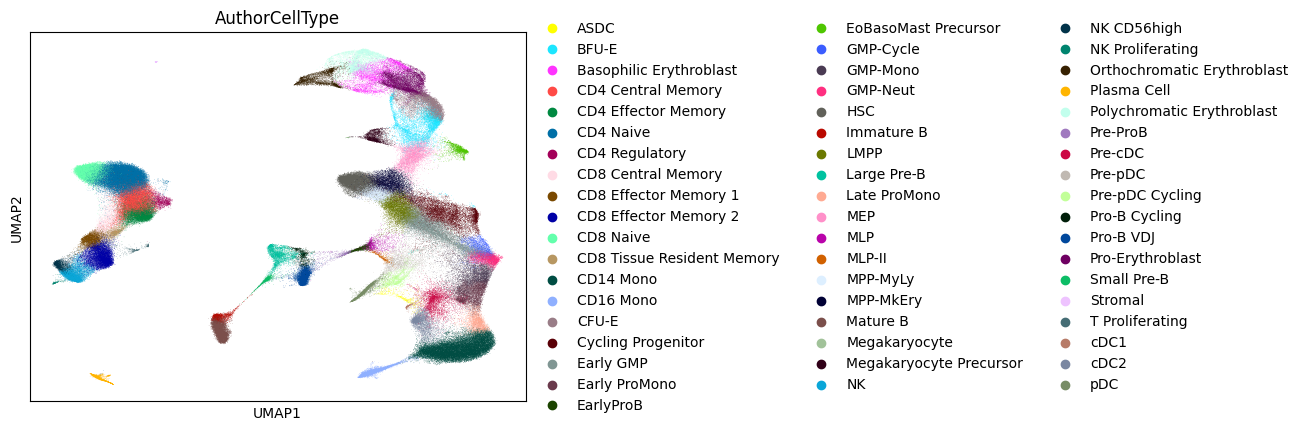

In [5]:
sc.pl.umap(adata, color=["AuthorCellType"])

In [6]:
adata_CD4_naive = adata[adata.obs["AuthorCellType"] == "CD4 Naive"]

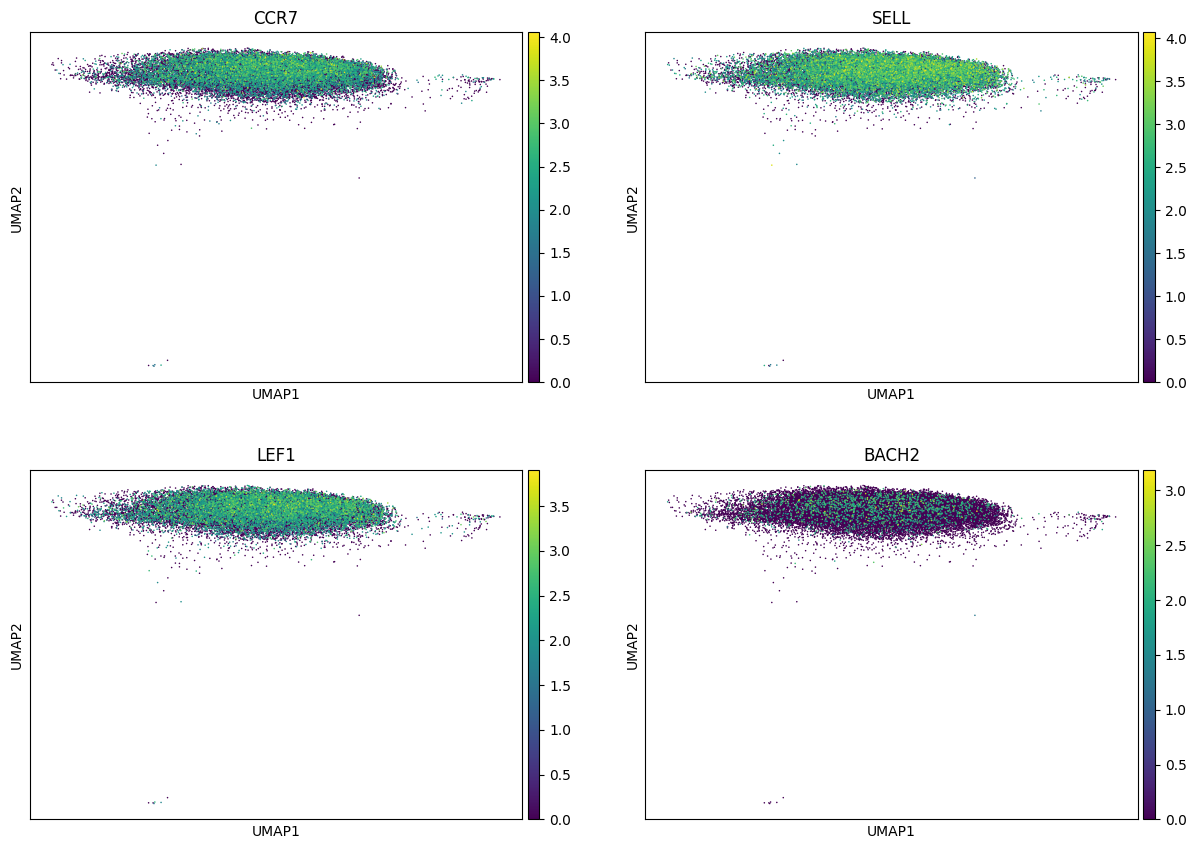

In [7]:
sc.pl.umap(adata_CD4_naive, color=["CCR7", "SELL", "LEF1", "BACH2"], ncols=2)

In [8]:
umap_x = adata_CD4_naive.obsm["X_umap"][:, 0]
umap_y = adata_CD4_naive.obsm["X_umap"][:, 1]


# remove outliers from UMAP plots
filtered_cells = (
    (umap_x < np.quantile(umap_x, 0.999)) &
    (umap_x > np.quantile(umap_x, 0.001)) &
    (umap_y < np.quantile(umap_y, 0.999)) &
    (umap_y > np.quantile(umap_y, 0.001))
)

adata_CD4_naive_plot = adata_CD4_naive[filtered_cells, :].copy()

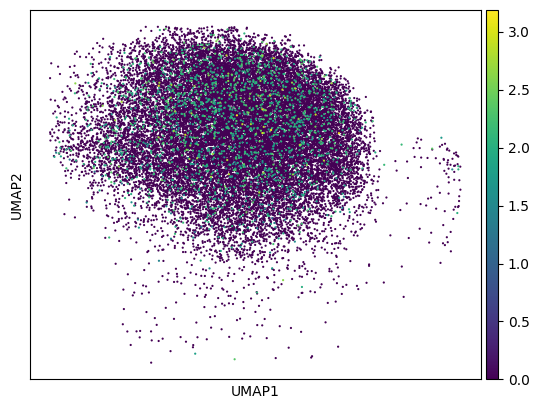

In [9]:
sc.pl.umap(adata_CD4_naive_plot, color=["BACH2"], save="_BACH2_bonemarrow.png", size=10, title="")

## Compate to van der Wijst

In [10]:
import scanpy as sc
import numpy as np

In [11]:
adata = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/raw/01ad3cd7-3929-4654-84c0-6db05bd5fd59.h5ad"
)

In [12]:
adata

AnnData object with n_obs × n_vars = 600929 × 18202
    obs: 'n_counts_mrna', 'NUM.SNPS', 'NUM.READS', 'DROPLET.TYPE', 'BEST.GUESS', 'percent_mito', 'pool', 'well', 'pool_well', 'batch', 'pool_clust', 'freemux_cluster', 'donor_id', 'timepoint', 'respiratory_support_D0', 'onset_to_D0_days', 'intubated_days', 'admission_to_discharge', 'D0_to_death', 'race', 'consent', 'death', 'pulmonary_infection', 'non_pulmonary_infection', 'leiden', 'onset_to_D0_days-as_float', 'original_leiden', 'ct1', 'ct2', 'ct3', 'WBC_count1', 'WBC_count2', 'WBC_count3', 'Lymphocyte_count', 'Monocyte_count', 'cell_group', 'exclude_restricted', 'IFN_shared_score', 'IFN_beta_score', 'IFN_gamma_score', 'days_from_start', 'COVID_status', 'admission_level', 'respiratory_support', 'NIH_clinical', 'COVID_severity', 'COVID_severity_merged', 'NIH_ordinal', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethni

In [13]:
del adata.raw

In [14]:
adata.var.index = adata.var["feature_name"].astype(str)

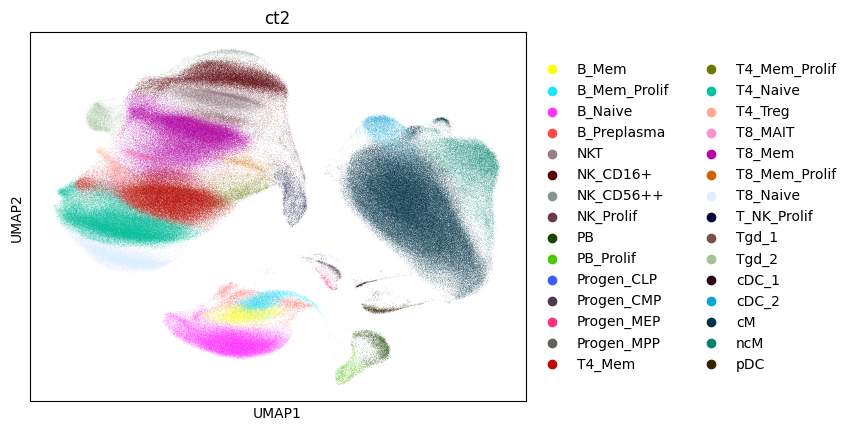

In [15]:
sc.pl.umap(adata, color=["ct2"])

In [16]:
adata_CD4_naive = adata[adata.obs["ct2"] == "T4_Naive"]

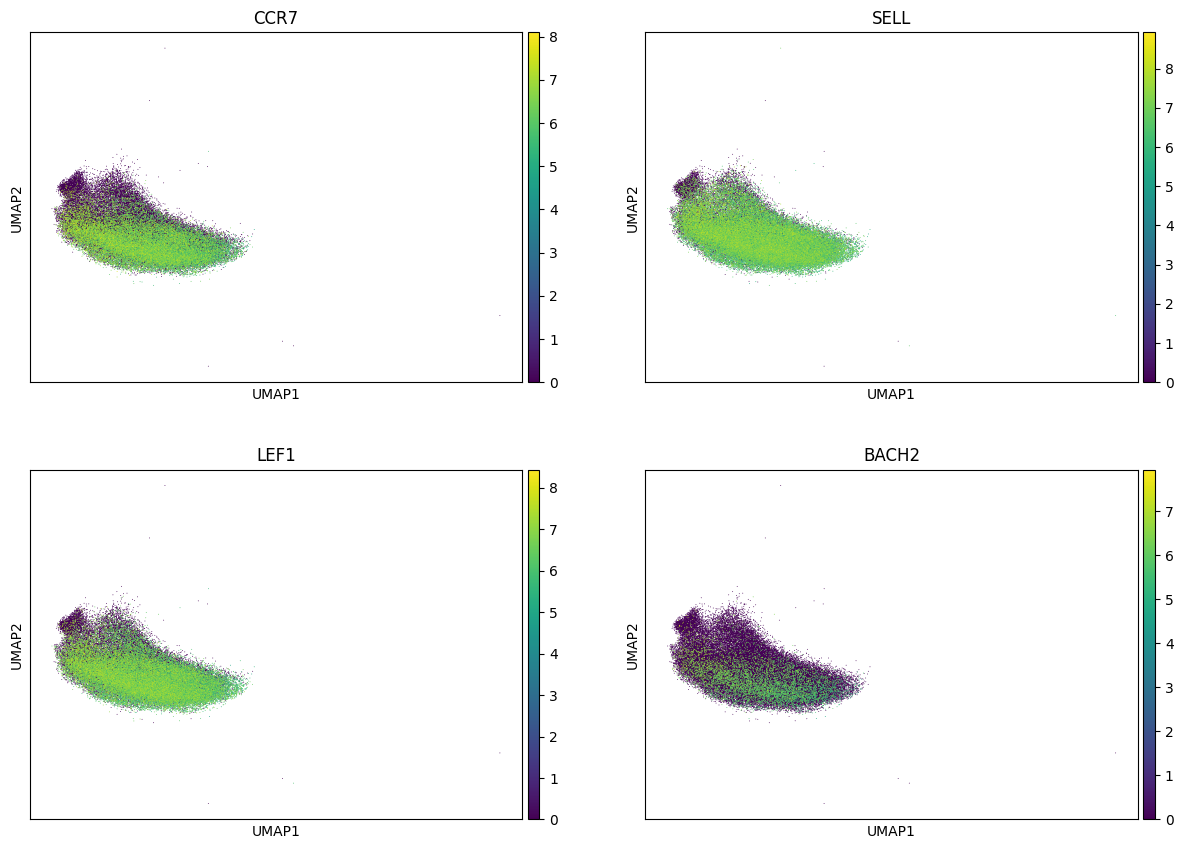

In [17]:
sc.pl.umap(adata_CD4_naive, color=["CCR7", "SELL", "LEF1", "BACH2"], ncols=2)

In [18]:
umap_x = adata_CD4_naive.obsm["X_umap"][:, 0]
umap_y = adata_CD4_naive.obsm["X_umap"][:, 1]


# remove outliers from UMAP plots
filtered_cells = (
    (umap_x < np.quantile(umap_x, 0.999)) &
    (umap_x > np.quantile(umap_x, 0.001)) &
    (umap_y < np.quantile(umap_y, 0.999)) &
    (umap_y > np.quantile(umap_y, 0.001))
)

adata_CD4_naive_plot = adata_CD4_naive[filtered_cells, :].copy()

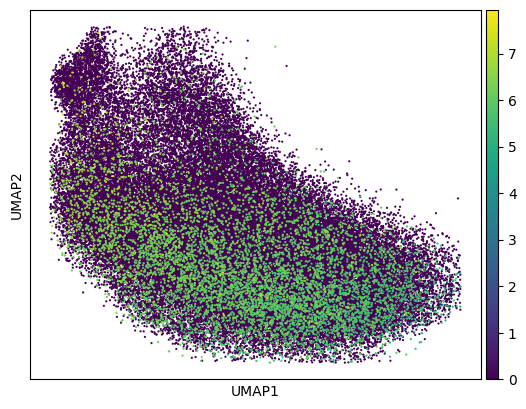

In [19]:
sc.pl.umap(adata_CD4_naive_plot, color=["BACH2"], save="_BACH2_van_der_wijst.png", size=10, title="")